## **Setup & Imports**

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import scorecardpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import pickle

current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [3]:
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/processed/train_final.csv')
print(f"Dataset Shape: {train.shape}")

Dataset Shape: (215257, 435)


## **Feature Selection via Information Value**

In [4]:
import importlib
import src.scorecard_utils as scorecard_utils
importlib.reload(scorecard_utils)

<module 'src.scorecard_utils' from 'c:\\Users\\Eren\\Desktop\\Credit_Risk_Analyse\\src\\scorecard_utils.py'>

In [5]:
train_sample = scorecard_utils.get_statistical_sample(
    df=train, 
    target_col='TARGET', 
    confidence_level=0.95, 
    margin_of_error=0.005 # %0.5 error margin 
)

Population Size (N)   : 215257
Confidence Level      : 95.0%
Margin of Error       : 0.5%
Calculated Sample Size (n): 32599


In [5]:
selected_features, iv_report = scorecard_utils.filter_features_by_iv(
    df=train_sample, 
    target_col='TARGET', 
    min_iv=0.02, 
    max_iv=0.50
)

display(iv_report.head(15))

Total features analyzed : 434
Features selected       : 185 (IV between 0.02 and 0.5)
Suspicious features     : 135 (IV > 0.5)
Useless features dropped: 114 (IV < 0.02)


,variable,info_value
0,PREV_CC_CC_UTILIZATION_MEAN_MAX,1.316401
1,PREV_CC_AMT_BALANCE_VAR_MIN,1.314843
2,PREV_CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN_MIN,1.314690
3,PREV_CC_CC_UTILIZATION_MEAN_MIN,1.314314
4,PREV_CC_AMT_BALANCE_MEAN_MIN,1.314184
5,PREV_CC_AMT_BALANCE_SUM_MIN,1.313063
6,PREV_CC_AMT_PAYMENT_TOTAL_CURRENT_SUM_MIN,1.307660
7,PREV_CC_AMT_INST_MIN_REGULARITY_MEAN_MIN,1.306571
8,PREV_CC_CC_UTILIZATION_MAX_MIN,1.306291
9,PREV_CC_AMT_BALANCE_MAX_MIN,1.304220


In [6]:
# Display the top 15 SAFE & SELECTED Predictors (0.02 <= IV <= 0.50)
print("\nTop 15 Selected Predictors:")
safe_iv_df = iv_report[iv_report['variable'].isin(selected_features)].reset_index(drop=True)
display(safe_iv_df.head(15))


Top 15 Selected Predictors:


,variable,info_value
0,BASEMENTAREA_AVG,0.498084
1,COMMONAREA_MODE,0.497835
2,LANDAREA_AVG,0.495097
3,BURO_BB_STATUS_X_SUM_MEAN,0.493660
4,COMMONAREA_AVG,0.492440
5,LANDAREA_MODE,0.491395
6,PREV_HOUR_APPR_PROCESS_START_MEAN,0.489891
7,APP_DTI_RATIO,0.482564
8,BURO_BB_STATUS_0_SUM_MEAN,0.477164
9,APARTMENTS_AVG,0.475753


In [ ]:
output_dir = '../data/processed/'
os.makedirs(output_dir, exist_ok=True)

pickle_path = os.path.join(output_dir, 'selected_features_iv.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump(selected_features, f)

txt_path = os.path.join(output_dir, 'selected_features_iv.txt')
with open(txt_path, 'w') as f:
    for feature in selected_features:
        f.write(f"{feature}\n")

print(f"Pickle File : {pickle_path}")
print(f"Text File   : {txt_path}")

## **Fine & Coarse Classing**

In [9]:
import gc
gc.collect()

3410

In [6]:
print("a.")

a.


In [8]:
filepath_txt = '../data/processed/selected_features_iv.txt'

with open(filepath_txt, 'r') as f:
    selected_features = [line.strip() for line in f.readlines()]

In [9]:
from optbinning import OptimalBinning
import pandas as pd
import numpy as np

x_train = train_sample[selected_features]
y_train = train_sample['TARGET'].values

binning_results = {}
train_woe = pd.DataFrame()
train_woe['TARGET'] = y_train


for col in selected_features:
    try:
        is_numeric = pd.api.types.is_numeric_dtype(x_train[col])
        dtype_param = "numerical" if is_numeric else "categorical"
        
        optb = OptimalBinning(
            name=col, 
            dtype=dtype_param, 
            solver="cp", 
            monotonic_trend="auto" 
        )
        
        # Fit and Transform (Ensure data is passed correctly based on type)
        col_data = x_train[col].values
        optb.fit(col_data, y_train)
        
        # Transform the original feature into its WoE representation
        train_woe[col] = optb.transform(col_data, metric="woe")
        
        # Save results for diagnostics
        binning_results[col] = optb
        
    except Exception as e:
        print(f"Failed to process feature '{col}': {e}")

print(f"Final WoE Dataframe Shape: {train_woe.shape}")
print(f"Features in WoE Matrix: {len(train_woe.columns) - 1}") # Excluding TARGET

Final WoE Dataframe Shape: (32599, 186)
Features in WoE Matrix: 185


--- Top Feature: BASEMENTAREA_AVG ---


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.07)",6053,0.185681,5595,458,0.075665,0.070407,0.000894,0.000112
1,"[0.07, 0.11)",3762,0.115402,3495,267,0.070973,0.139487,0.002118,0.000265
2,"[0.11, 0.16)",2147,0.065861,2027,120,0.055892,0.394468,0.008697,0.001080
3,"[0.16, inf)",1644,0.050431,1547,97,0.059002,0.337009,0.004977,0.000619
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,18993,0.582625,17303,1690,0.088980,-0.106201,0.006871,0.000858
Totals,,32599,1.000000,29967,2632,0.080739,,0.023557,0.002934



--- WoE Trend for BASEMENTAREA_AVG ---


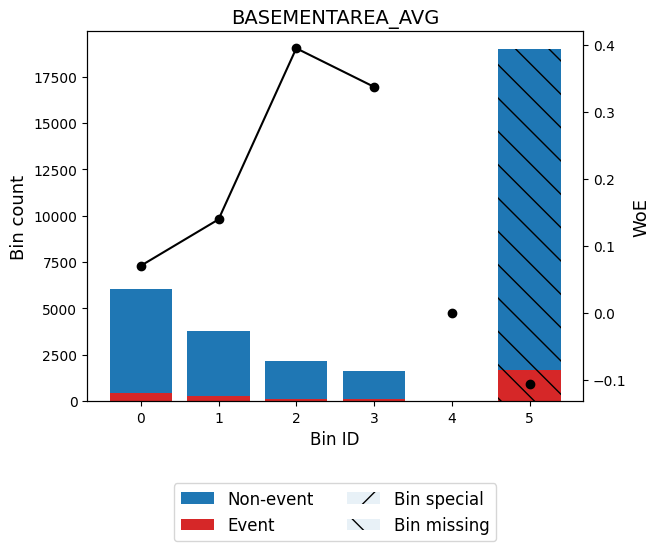

Feature: BASEMENTAREA_AVG
Status: OPTIMAL
Total IV: 0.0236


In [10]:
import matplotlib.pyplot as plt

top_feature = selected_features[0]

print(f"--- Top Feature: {top_feature} ---")

optb = binning_results[top_feature]

binning_table = optb.binning_table.build()
display(binning_table)

print(f"\n--- WoE Trend for {top_feature} ---")
optb.binning_table.plot(metric="woe")
plt.show()

print(f"Feature: {top_feature}")
print(f"Status: {optb.status}")
print(f"Total IV: {optb.binning_table.iv:.4f}")

In [12]:
import importlib
import src.scorecard_utils as scorecard_utils
importlib.reload(scorecard_utils)

df_health = scorecard_utils.run_feature_health_check(binning_results)

test_col = selected_features[0]
test_bt = binning_results[test_col].binning_table.build()

print(f"--- [DEBUG] Raw Binning Table for {test_col} ---")
display(test_bt)

critical_list = scorecard_utils.get_health_summary(df_health)

--- [DEBUG] Raw Binning Table for BASEMENTAREA_AVG ---


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.07)",6053,0.185681,5595,458,0.075665,0.070407,0.000894,0.000112
1,"[0.07, 0.11)",3762,0.115402,3495,267,0.070973,0.139487,0.002118,0.000265
2,"[0.11, 0.16)",2147,0.065861,2027,120,0.055892,0.394468,0.008697,0.001080
3,"[0.16, inf)",1644,0.050431,1547,97,0.059002,0.337009,0.004977,0.000619
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,18993,0.582625,17303,1690,0.088980,-0.106201,0.006871,0.000858
Totals,,32599,1.000000,29967,2632,0.080739,,0.023557,0.002934



      FEATURE STABILITY AUDIT SUMMARY
Health_Score
STABLE                                            116
CRITICAL: High Missing                             32
CRITICAL: High Missing, Insufficient Bins          17
CRITICAL: Over-Concentrated, Insufficient Bins     15
CRITICAL: Insufficient Bins                         3
CRITICAL: Over-Concentrated                         2
Name: count, dtype: int64
--------------------------------------------------


In [14]:
import pandas as pd

stable_txt_path = '../data/processed/stable_features_v1.txt'
stable_csv_path = '../data/processed/train_woe_stable_116.csv'

final_stable_features = df_health[df_health["Health_Score"] == "STABLE"]["Feature"].tolist()

with open(stable_txt_path, 'w') as f:
    for feature in final_stable_features:
        f.write(f"{feature}\n")

train_woe_filtered = train_woe[final_stable_features + ['TARGET']]
train_woe_filtered.to_csv(stable_csv_path, index=False)

print(f"Stable Features List: {len(final_stable_features)} variables saved to TXT.")

Stable Features List: 116 variables saved to TXT.


## **Correlation Filtering**

In [15]:
import importlib
import src.scorecard_utils as scorecard_utils
importlib.reload(scorecard_utils)

uncorrelated_features = scorecard_utils.filter_by_correlation(
    df_woe=train_woe_filtered, 
    binning_results=binning_results, 
    threshold=0.80
)

print(f"Variables remaining after Correlation Filter: {len(uncorrelated_features)}")

Initial features: 116
Features dropped due to high correlation: 19
Remaining features: 97
Variables remaining after Correlation Filter: 97


## **VFI**

In [16]:
import importlib
import src.scorecard_utils as scorecard_utils
importlib.reload(scorecard_utils)

vif_report = scorecard_utils.calculate_vif(train_woe_filtered, uncorrelated_features)

high_vif = vif_report[vif_report["VIF"] > 5]

print(f"Features with VIF > 5: {len(high_vif)}")
display(high_vif.head(10))

Features with VIF > 5: 2


,feature,VIF
57,YEARS_BEGINEXPLUATATION_AVG,5.705572
55,BURO_CREDIT_TYPE_Credit card_SUM,5.050952


In [17]:
feature_to_drop = "YEARS_BEGINEXPLUATATION_AVG"
final_modeling_features = [f for f in uncorrelated_features if f != feature_to_drop]

final_vif_report = scorecard_utils.calculate_vif(train_woe_filtered, final_modeling_features)

print(f"Features remaining: {len(final_modeling_features)}")
display(final_vif_report.head(5))

with open('../data/processed/final_modeling_features_v3.txt', 'w') as f:
    for feat in final_modeling_features:
        f.write(f"{feat}\n")

Features remaining: 96


,feature,VIF
55,BURO_CREDIT_TYPE_Credit card_SUM,5.050412
27,PREV_INS_AMT_PAYMENT_SUM_MAX,4.881968
10,BURO_CREDIT_ACTIVE_Active_SUM,4.759175
82,PREV_POS_POS_STAT_Completed_MEAN_MAX,4.601992
72,PREV_AMT_ANNUITY_SUM,4.453096


## **5Cs of Credit Inspect**

In [19]:
print(f"--- TOTAL FEATURES: {len(final_modeling_features)} ---")
for i, feature in enumerate(final_modeling_features, 1):
    print(f"{i}. {feature}")

--- TOTAL FEATURES: 96 ---
1. EXT_SOURCE_2
2. PREV_INS_AMT_PAYMENT_MIN_MEAN
3. ORGANIZATION_TYPE
4. BURO_CREDIT_ACTIVE_Active_MEAN
5. DAYS_BIRTH
6. BURO_DAYS_CREDIT_ENDDATE_MEAN
7. PREV_LTV_RATIO_MEAN
8. BURO_DAYS_CREDIT_MIN
9. OCCUPATION_TYPE
10. BURO_DAYS_ENDDATE_FACT_MIN
11. BURO_CREDIT_ACTIVE_Active_SUM
12. PREV_INS_AMT_INSTALMENT_MAX_MAX
13. REGION_RATING_CLIENT_W_CITY
14. NAME_INCOME_TYPE
15. DAYS_LAST_PHONE_CHANGE
16. PREV_INS_AMT_INSTALMENT_MAX_MEAN
17. PREV_INS_AMT_INSTALMENT_MEAN_SUM
18. PREV_DAYS_LAST_DUE_MIN
19. PREV_AMT_ANNUITY_MEAN
20. DAYS_ID_PUBLISH
21. PREV_INS_AMT_INSTALMENT_MEAN_MAX
22. PREV_INS_AMT_INSTALMENT_MAX_SUM
23. PREV_INS_INS_DPD_MAX_MAX
24. PREV_AMT_ANNUITY_MIN
25. REGION_POPULATION_RELATIVE
26. FLAG_DOCUMENT_3
27. PREV_INS_AMT_INSTALMENT_MEAN_MEAN
28. PREV_INS_AMT_PAYMENT_SUM_MAX
29. FLOORSMAX_AVG
30. PREV_INS_AMT_INSTALMENT_SUM_SUM
31. PREV_POS_SK_DPD_DEF_MAX_MEAN
32. DAYS_REGISTRATION
33. PREV_CNT_PAYMENT_MIN
34. CODE_GENDER
35. PREV_POS_CNT_INSTALMENT_M

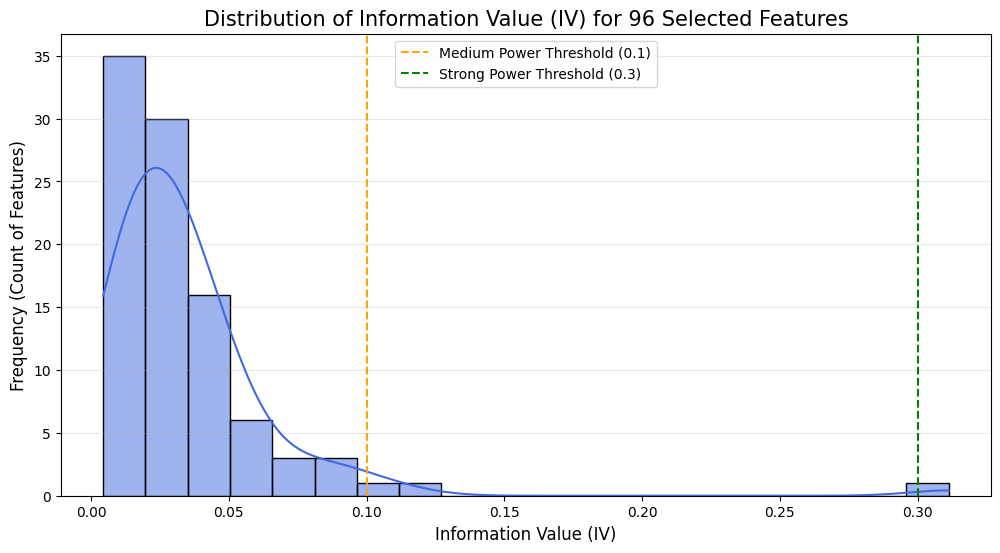

--- IV Summary Statistics ---
count    96.000000
mean      0.034434
std       0.035910
min       0.004391
25%       0.016011
50%       0.027797
75%       0.040845
max       0.311257
Name: IV, dtype: float64

Weak Predictors (0.02 - 0.1): 94
Medium Predictors (0.1 - 0.3): 1
Strong Predictors (0.3 - 0.5): 1


In [20]:
iv_data = []
for feature in final_modeling_features:
    iv_value = binning_results[feature].binning_table.iv
    iv_data.append({'Feature': feature, 'IV': iv_value})

df_iv = pd.DataFrame(iv_data).sort_values(by='IV', ascending=False)

plt.figure(figsize=(12, 6))

sns.histplot(df_iv['IV'], bins=20, kde=True, color='royalblue', edgecolor='black')

plt.axvline(x=0.1, color='orange', linestyle='--', label='Medium Power Threshold (0.1)')
plt.axvline(x=0.3, color='green', linestyle='--', label='Strong Power Threshold (0.3)')

plt.title('Distribution of Information Value (IV) for 96 Selected Features', fontsize=15)
plt.xlabel('Information Value (IV)', fontsize=12)
plt.ylabel('Frequency (Count of Features)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("--- IV Summary Statistics ---")
print(df_iv['IV'].describe())

weak_count = len(df_iv[df_iv['IV'] < 0.1])
medium_count = len(df_iv[(df_iv['IV'] >= 0.1) & (df_iv['IV'] < 0.3)])
strong_count = len(df_iv[df_iv['IV'] >= 0.3])

print(f"\nWeak Predictors (0.02 - 0.1): {weak_count}")
print(f"Medium Predictors (0.1 - 0.3): {medium_count}")
print(f"Strong Predictors (0.3 - 0.5): {strong_count}")


--- Analysis for: EXT_SOURCE_2 ---


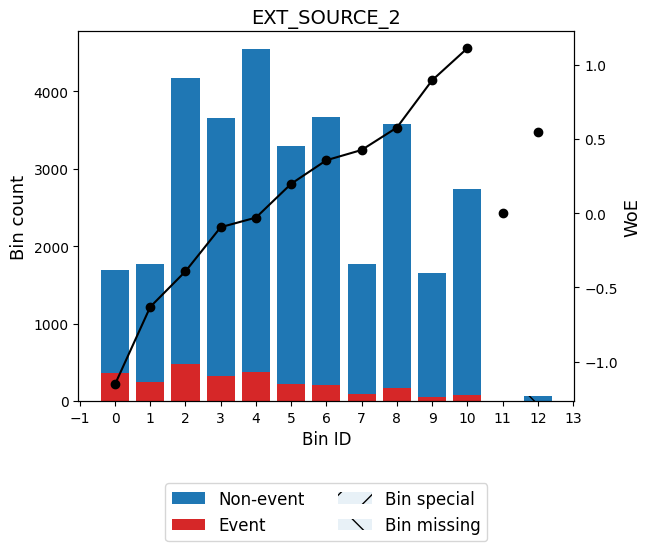


--- Analysis for: PREV_LTV_RATIO_SUM ---


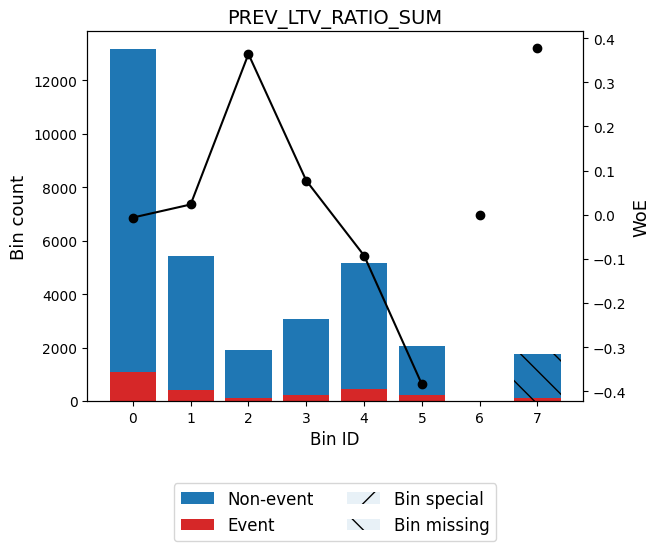

In [21]:
import matplotlib.pyplot as plt

top_feature = df_iv.iloc[0]['Feature']

weak_feature = df_iv.iloc[50]['Feature'] 

def plot_woe_comparison(feature_name):
    print(f"\n--- Analysis for: {feature_name} ---")
    optb = binning_results[feature_name]
    
    optb.binning_table.plot(metric="woe")

plot_woe_comparison(top_feature)
plot_woe_comparison(weak_feature)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. Performance with only the Top Feature (e.g., EXT_SOURCE_2 with IV ~0.31)
X_top = train_woe_filtered[[top_feature]]
y = train_woe_filtered['TARGET']

model_single = LogisticRegression()
model_single.fit(X_top, y)
single_probs = model_single.predict_proba(X_top)[:, 1]
auc_single = roc_auc_score(y, single_probs)
gini_single = 2 * auc_single - 1

# 2. Performance with the full set of 96 Features
X_all = train_woe_filtered[final_modeling_features]
model_all = LogisticRegression()
model_all.fit(X_all, y)
all_probs = model_all.predict_proba(X_all)[:, 1]
auc_all = roc_auc_score(y, all_probs)
gini_all = 2 * auc_all - 1

# 3. Output the results
print(f"Single Variable Gini: {gini_single:.4f}")
print(f"96 Features Gini    : {gini_all:.4f}")

# Calculate the uplift
improvement = ((gini_all / gini_single) - 1) * 100
print(f"Model Lift (Gain from weak features): {improvement:.2f}%")

Single Variable Gini: 0.3032
96 Features Gini    : 0.5228
Model Lift (Gain from weak features): 72.44%
